# World Cup 2026 Analytics — Exploratory Data Analysis
This notebook covers data validation, feature distributions (Elo ratings vs. Market Values), and K-Means player style clustering tests.

In [4]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix path to load modules from data/ and src/
sys.path.append(os.path.abspath(os.path.join('..')))
from data.teams_data import TEAMS_DB, team_list, get_rank, get_market_value, get_base_elo
from src.player_clustering.clusterer import PlayerStyleClusterer, SAMPLE_PLAYERS

sns.set_theme(style="darkgrid")

Total teams loaded: 48


,team,rank,market_value,elo,iso
0,Argentina,1,1250.0,2120.0,AR
1,France,2,1225.5,2106.5,FR
2,Brazil,3,1201.0,2093.0,BR
3,England,4,1176.5,2079.5,GB
4,Belgium,5,1152.0,2066.0,BE
5,Portugal,6,1127.5,2052.5,PT
6,Netherlands,7,1103.0,2039.0,NL
7,Spain,8,1078.5,2025.5,ES
8,Croatia,9,1054.0,2012.0,HR
9,Italy,10,1029.5,1998.5,IT


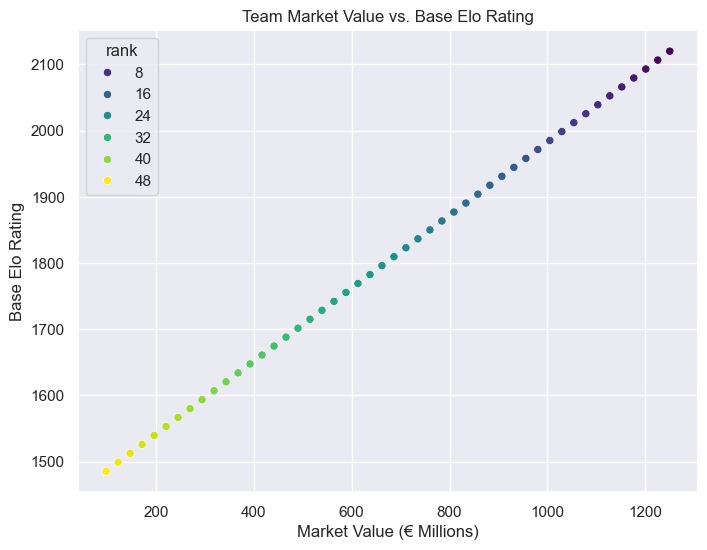

In [5]:
# Convert TEAMS_DB dictionary into a DataFrame for exploration
teams_df = pd.DataFrame([
    {"team": name, "rank": data[0], "market_value": data[1], "elo": data[2], "iso": data[3]}
    for name, data in TEAMS_DB.items()
])

print(f"Total teams loaded: {len(teams_df)}")
display(teams_df.head(10))

# Quick correlation check
plt.figure(figsize=(8, 6))
sns.scatterplot(data=teams_df, x="market_value", y="elo", hue="rank", palette="viridis")
plt.title("Team Market Value vs. Base Elo Rating")
plt.xlabel("Market Value (€ Millions)")
plt.ylabel("Base Elo Rating")
plt.show()

Cluster Groupings:


,player_name,team,style
0,Kylian Mbappe,France,Pacey Dribbler / Winger
1,Erling Haaland,Norway,Attacking Full-Back
2,Jude Bellingham,England,Deep-Lying Playmaker
3,Vinicius Jr.,Brazil,Pacey Dribbler / Winger
4,Rodri,Spain,Deep-Lying Playmaker
5,Toni Kroos,Germany,Deep-Lying Playmaker
6,Virgil van Dijk,Netherlands,Ball-Winning Defender
7,Ruben Dias,Portugal,Ball-Winning Defender
8,Bukayo Saka,England,Pacey Dribbler / Winger
9,Lamine Yamal,Spain,Pacey Dribbler / Winger


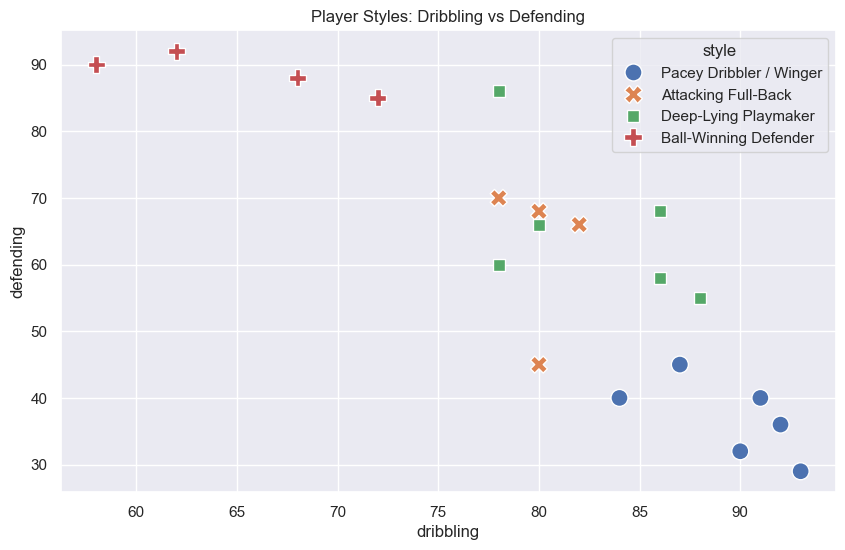

In [6]:
# Initialize clusterer and fit sample players
clusterer = PlayerStyleClusterer(n_clusters=4)
clustered_players = clusterer.cluster_players(SAMPLE_PLAYERS)

print("Cluster Groupings:")
display(clustered_players[["player_name", "team", "style"]])

# Visualize attribute spread across styles
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clustered_players, 
    x="dribbling", 
    y="defending", 
    hue="style", 
    style="style", 
    s=150
)
plt.title("Player Styles: Dribbling vs Defending")
plt.show()